# Estrutura do Notebook: Análise Não-Supervisionada
Esta parte inicial foca em entender a estrutura dos datasets.

## Dataset 1: Consumo de Energia

### Preparação e Limpeza

Focando em como as técnicas não supervisionadas ajudam a identificar possíveis perfis1

In [ ]:
# Importação das Bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors


In [ ]:
# Carregamento do dataset
df1 = pd.read_csv('dataset/EV_Usage_Dataset_v2.csv')

df1_features = []

# Limpeza Inicial
df1 = df1.dropna(how='all')
df1_numeric = df1[df1_features].fillna(df1[df1_features].median())
scaler = StandardScaler()
X1_scaled = scaler.fit_transform(df1_numeric)

### Aplicação de PCA
Para reduzir para 2 componentes

Variância explicada pelos 2 componentes: 0.48


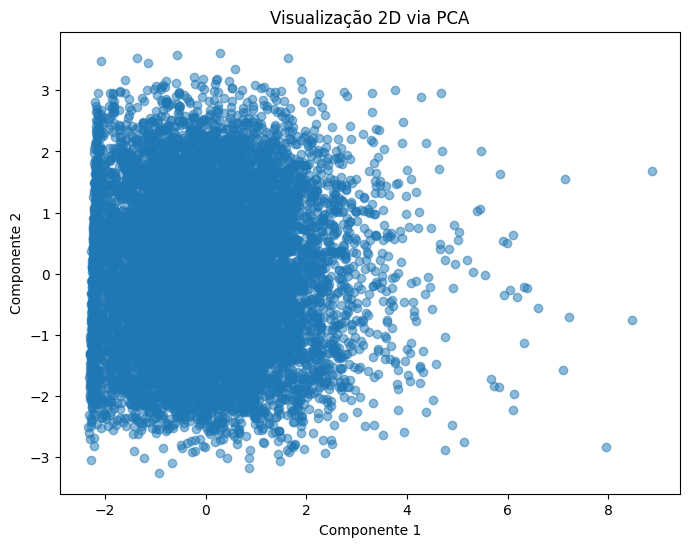

In [ ]:
pca = PCA(n_components=2)
X1_pca = pca.fit_transform(X1_scaled)

print(f"Variância explicada pelos 2 componentes: {sum(pca.explained_variance_ratio_):.2f}")

plt.figure(figsize=(8, 6))
plt.scatter(X1_pca[:, 0], X1_pca[:, 1], alpha=0.5)
plt.title('Visualização 2D via PCA')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.show()

**Discussão:** 


### Agrupamento com K-Means

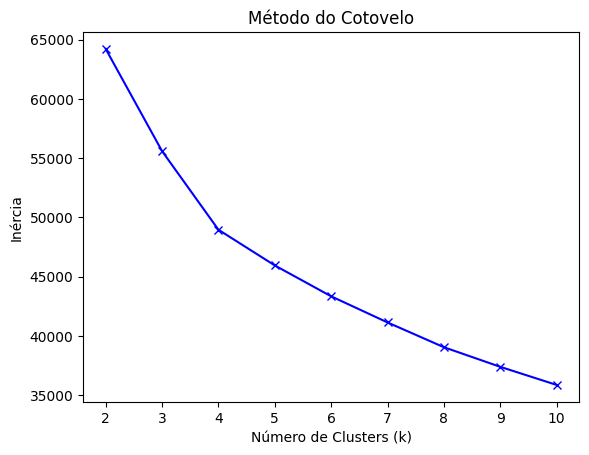

In [ ]:
inertia1 = []
K_range1 = range(2, 11)

for k in K_range1:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X1_scaled)
    inertia1.append(kmeans.inertia1_)

plt.plot(K_range1, inertia1, 'bx-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo')
plt.show()

In [ ]:
# Avaliando os melhores candidatos do Cotovelo (k=3 e k=4)
k1_candidatos = [3, 4]

print("Silhouette Score -> maior é melhor")
print("Davies-Bouldin -> menor é melhor")
print("Calinski-Harabasz -> maior é melhor\n")

for k in k1_candidatos:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X1_scaled)
    
    sil_score = silhouette_score(X1_scaled, labels)
    db_score = davies_bouldin_score(X1_scaled, labels)
    ch_score = calinski_harabasz_score(X1_scaled, labels)

    print(f"--- Métricas para K={k} ---")
    print(f"Silhouette Score: {sil_score:.4f}")
    print(f"Davies-Bouldin: {db_score:.4f}")
    print(f"Calinski-Harabasz: {ch_score:.4f}\n")

Silhouette Score -> maior é melhor
Davies-Bouldin -> menor é melhor
Calinski-Harabasz -> maior é melhor

--- Métricas para K=3 ---
Silhouette Score: 0.1510
Davies-Bouldin: 1.8158
Calinski-Harabasz: 2063.9141

--- Métricas para K=4 ---
Silhouette Score: 0.1673
Davies-Bouldin: 1.5947
Calinski-Harabasz: 2056.3559



In [ ]:
# Treinando o modelo final com o K vencedor
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df1['Cluster_KMeans'] = kmeans_final.fit_predict(X1_scaled)

# Agrupando os dados originais (sem escala) para ver as médias reais
perfis1 = df1[df1_features + ['Cluster_KMeans']].groupby('Cluster_KMeans').mean()

# Mostrando a tabela formatada
display(perfis1.round(2))

,battery_capacity_kwh,battery_health_pct,distance_km,daily_trip_count,charging_frequency_per_week,charging_duration_min,energy_consumed_kwh
Cluster_KMeans,,,,,,,
0,40.27,89.49,24.48,2.54,3.22,178.14,4.09
1,5.05,96.00,18.11,2.51,2.15,178.78,2.99
2,5.06,82.17,19.94,2.53,4.58,174.28,3.30
3,6.57,89.95,45.90,2.50,3.19,188.83,7.50


**Discussão:**



### Agrupamento com DBSCAN
Procurando por outliers

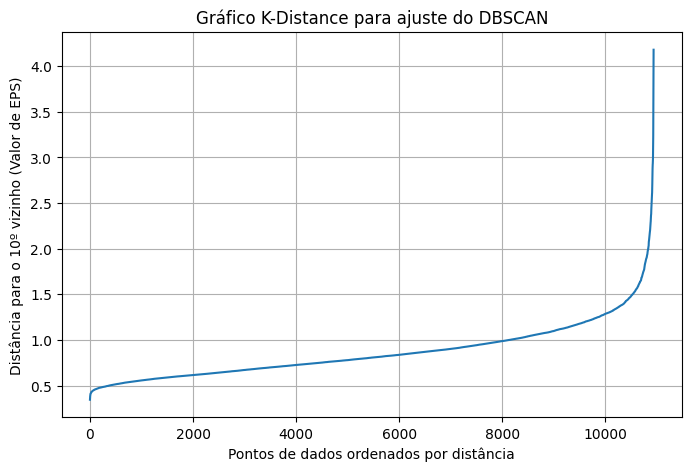

In [ ]:
# Deixando o min_samples = 10 como base
min_pts = 10 

# Calculando a distância de cada ponto para o seu 10º vizinho mais próximo
neighbors = NearestNeighbors(n_neighbors=min_pts)
neighbors_fit = neighbors.fit(X1_scaled)
distances, indices = neighbors_fit.kneighbors(X1_scaled)

# Pegando apenas a distância para o 10º vizinho e ordenando
distances = np.sort(distances[:, min_pts-1], axis=0)

# Plotando o gráfico K-Distance
plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.title('Gráfico K-Distance para ajuste do DBSCAN')
plt.xlabel('Pontos de dados ordenados por distância')
plt.ylabel(f'Distância para o {min_pts}º vizinho (Valor de EPS)')
plt.grid(True)
plt.show()

O valor de EPS será X então

In [ ]:
# Rodando o DBSCAN
# eps: raio de busca (distância) / min_samples: pontos mínimos para formar um cluster
dbscan = DBSCAN(eps=1.5, min_samples=10)
df1['Cluster_DBSCAN'] = dbscan.fit_predict(X1_scaled)

# Avaliando os resultados
n_clusters_ = len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0)
n_noise_ = list(dbscan.labels_).count(-1)

print(f"Número de Clusters encontrados: {n_clusters_}")
print(f"Número de Anomalias/Outliers (Ruído): {n_noise_}")

# máscara para filtrar os outliers
mask = dbscan.labels_ != -1

# O DBSCAN vai precisar de pelo menos 2 clusters (além do ruído) para calcular as métricas
if n_clusters_ > 1:
    sil_db = silhouette_score(X1_scaled[mask], dbscan.labels_[mask])
    db_score_db = davies_bouldin_score(X1_scaled[mask], dbscan.labels_[mask])
    ch_score_db = calinski_harabasz_score(X1_scaled[mask], dbscan.labels_[mask])
    
    print(f"Silhouette Score (sem ruído): {sil_db:.4f}")
    print(f"Davies-Bouldin (sem ruído): {db_score_db:.4f}")
    print(f"Calinski-Harabasz (sem ruído): {ch_score_db:.4f}")
else:
    print("Métricas de distância (Silhouette, DB, CH) não aplicáveis.")
    print("Motivo: O DBSCAN encontrou apenas 1 cluster principal contínuo e anomalias espalhadas.")
    print("Essas métricas exigem no mínimo 2 clusters válidos para calcular a separação geométrica.")

Número de Clusters encontrados: 1
Número de Anomalias/Outliers (Ruído): 160
Métricas de distância (Silhouette, DB, CH) não aplicáveis.
Motivo: O DBSCAN encontrou apenas 1 cluster principal contínuo e anomalias espalhadas.
Essas métricas exigem no mínimo 2 clusters válidos para calcular a separação geométrica.


**Discussão:**


### Conclusão


#### Tabela de Métricas de Agrupamento


## Dataset 2: Classificação de Clima